In [1]:
%load_ext autoreload

In [184]:
%autoreload 2
%aimport sog1_helpers

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import protfasta

import warnings

# Ignore all warnings
warnings.filterwarnings('ignore')

#plt.rcParams['text.usetex'] = True

plt.rcParams['ps.fonttype'] = 42
plt.rcParams["font.family"] = "Helvetica" #somethings this one doesnt work
plt.rcParams['pdf.fonttype'] = 42

activity_col = "Activity_S3_1"

In [185]:
# 1. Obtain ortholog and NAC family tiles

In [186]:
# Reading in the wt tiles of all sog1 orthologs and nac family tiles
basic_tiles = sog1_helpers.return_activities("Basic", pos_regex = "")
basic_tiles["name"] = basic_tiles["Other"].str.split("_").str[0]
basic_tiles["name"] = basic_tiles["name"].str.replace("SOG1", "")
basic_tiles["name"] = basic_tiles["name"].str.strip()
basic_tiles["Tile_Description"] = basic_tiles["Description"].str.split("_").str[0]
basic_tiles = basic_tiles[basic_tiles["Start"] != "?"]
basic_tiles["mid"] = basic_tiles["Start"].astype(int) + 19
basic_tiles

,Start,End,Description,Other,tile,Activity_S3_1,Activity_S3_2,lib2_avg,name,Tile_Description,mid
0,1,40,Basic6.1,Q9LR74,MKILPVGSRFCPTDLGLVRLYLRNKVERNQSSFITTMDIH,586.178097,NaN,586.178097,Q9LR74,Basic6.1,20
1,11,50,Basic6.2,Q9LR74,CPTDLGLVRLYLRNKVERNQSSFITTMDIHQDYPWLLPHV,2211.966071,2343.749322,2277.857696,Q9LR74,Basic6.2,30
2,21,60,Basic6.3,Q9LR74,YLRNKVERNQSSFITTMDIHQDYPWLLPHVNNPLFNNNEW,NaN,NaN,NaN,Q9LR74,Basic6.3,40
3,31,70,Basic6.4,Q9LR74,SSFITTMDIHQDYPWLLPHVNNPLFNNNEWYYFVPLTERG,573.518390,599.219717,586.369054,Q9LR74,Basic6.4,50
4,41,80,Basic6.5,Q9LR74,QDYPWLLPHVNNPLFNNNEWYYFVPLTERGGKILSVHRKV,315.722705,392.863309,354.293007,Q9LR74,Basic6.5,60
...,...,...,...,...,...,...,...,...,...,...,...
3012,371,410,BasicArTh.38,Q6NQK2,GSQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,601.553077,3400.972046,2001.262561,Q6NQK2,BasicArTh.38,390
3013,381,420,BasicArTh.39,Q6NQK2,SGSLKDKQPCIADYAHLGPEDFKRDLEECQKIVLDPSNIE,508.338058,1512.228706,1010.283382,Q6NQK2,BasicArTh.39,400
3014,391,430,BasicArTh.40,Q6NQK2,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDTPPEFRLS,1960.462356,1783.792784,1872.127570,Q6NQK2,BasicArTh.40,410
3015,401,440,BasicArTh.41,Q6NQK2,DFKRDLEECQKIVLDPSNIELDTPPEFRLSQLEFGSQDSF,2216.350444,2335.951103,2276.150773,Q6NQK2,BasicArTh.41,420


In [187]:
sog1_orthologs = pd.read_csv("../data/sog1_orthologs.csv", sep = "\t")
sog1_orthologs["name"] = sog1_orthologs["Wild type sequences:"].str.split("_").str[0]
sog1_orthologs["name"] = sog1_orthologs["name"].str.replace("SOG1", "")
sog1_orthologs["name"] = sog1_orthologs["name"].str.strip()
ArTh_wt = "".join(pd.read_csv("../data/Sog1_AA_features.csv")["aa"])
sog1_orthologs.loc[15] = {"name" : "Q6NQK2", "Unnamed: 1" : ArTh_wt}
sog1_orthologs

,Wild type sequences:,Unnamed: 1,name
0,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNS...,B.rapa
1,S.bicolor_Sobic.010G111800.2.p_Macovei,MPRRFFFFAVDGSSGQMMTFLYFGFNDKEDMSTVRMKTTWIIDSQR...,S.bicolor
2,E.grandis_Eucgr.G02349.1.p_Macovei,MAGPSWLVDSHRIATKIRSASGASDPEKVKWKSNPTRACPNCQHVI...,E.grandis
3,V.vinifera peptide_GSVIVT01011954001_Macovei,MSWLVDSNRFATKIKNASGTRETERVKWKSNPSRACPNCQHIIDNS...,V.vinifera peptide
4,PopulusTrichocarpaSOG1_Lib1,MAGPWLVDGNRFATKIKSASSASNHERVAWKSDPCKTCPNCHHVID...,PopulusTrichocarpa
5,Nicotianatabacum(tobacco)_A0A1S3X2K2_TAIR,MCYRFRRPSWLVDSKRIATKIKSASGDPGAVNWKSNPTKACPNCQF...,Nicotianatabacum(tobacco)
6,G.max_Glyma.10G204700.1.p_Macovei,MAGPSWLVDKSRIATKIKNVSGTCGKVIWKSNPSRACPSCHHVIDN...,G.max
7,Selaginellamoellendorffii(spikemoss)_D8RBR5_TAIR,MSQAPQDWTGLPAGVKFDPNDKEILDHLAAKIGRGGKPHALIDEFI...,Selaginellamoellendorffii(spikemoss)
8,MarchantiaPolymorphaSOG1_Lib1,MKNRDHRDRWGRFMDQLVRQIDNATHQRNDAYSLAQDDTTALPGLE...,MarchantiaPolymorpha
9,PhyscomitriumPatensSOG1_Lib1,MDRVASNRILGASKLRCDNNAAAHVKLDSFPAGVRFDPSDEELLEH...,PhyscomitriumPatens


In [188]:
orthologs = basic_tiles[basic_tiles["name"].isin(sog1_orthologs["name"])]
orthologs["Description_name"] = orthologs["Description"].str.split(".").str[0]
orthologs["Description_name"].value_counts()

Description_name
BasicNeSa    131
BasicSoBi    120
BasicZeMa    111
BasicBrDi    104
BasicOrSa    103
BasicNiTa     99
BasicGlMa     98
BasicBrRa     96
BasicPoTr     94
BasicEuGr     92
BasicViVi     88
BasicPhPa     84
BasicMaPo     70
BasicArTh     42
BasicAmTr     38
BasicSeMo     17
Name: count, dtype: int64

In [189]:
ortholog_name_mapping  = pd.read_csv("../output/ortholog_name_mapping.csv")
ortholog_name_mapping

,Unnamed: 0,Other,Description_name,standard_name,name
0,471,B.rapa_Brara.G00896.1.p_Macovei,BasicBrRa,B.rapa,B.rapa
1,567,S.bicolor_Sobic.010G111800.2.p_Macovei,BasicSoBi,S.bicolor,S.bicolor
2,687,E.grandis_Eucgr.G02349.1.p_Macovei,BasicEuGr,E.grandis,E.grandis
3,779,V.vinifera peptide_GSVIVT01011954001_Macovei,BasicViVi,V.vinifera,V.vinifera
4,867,PopulusTrichocarpaSOG1_Lib1,BasicPoTr,P.Trichocarpa,PopulusTrichocarpa
5,961,Nicotianatabacum(tobacco)_A0A1S3X2K2_TAIR,BasicNiTa,N.Tabacaum,Nicotianatabacum(tobacco)
6,1060,G.max_Glyma.10G204700.1.p_Macovei,BasicGlMa,G.max,G.max
7,1158,Selaginellamoellendorffii(spikemoss)_D8RBR5_TAIR,BasicSeMo,S.Moellendorffii,Selaginellamoellendorffii(spikemoss)
8,1175,MarchantiaPolymorphaSOG1_Lib1,BasicMaPo,M.Polymorpha,MarchantiaPolymorpha
9,1245,PhyscomitriumPatens_PpSOG1a,BasicPhPa,P.Patens,PhyscomitriumPatens


In [190]:
orthologs = pd.merge(orthologs, ortholog_name_mapping[["Description_name", "standard_name"]], how = "left")
orthologs

,Start,End,Description,Other,tile,Activity_S3_1,Activity_S3_2,lib2_avg,name,Tile_Description,mid,Description_name,standard_name
0,1,40,BasicBrRa.1,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCH,372.197467,436.667606,404.432536,B.rapa,BasicBrRa.1,20,BasicBrRa,B.rapa
1,11,50,BasicBrRa.2,B.rapa_Brara.G00896.1.p_Macovei,NRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNSHEVD,NaN,NaN,NaN,B.rapa,BasicBrRa.2,30,BasicBrRa,B.rapa
2,21,60,BasicBrRa.3,B.rapa_Brara.G00896.1.p_Macovei,SDPCPTVWNTNPTRHCPNCHHVIDNSHEVDDWPGLPRGVK,765.501115,715.751065,740.626090,B.rapa,BasicBrRa.3,40,BasicBrRa,B.rapa
3,31,70,BasicBrRa.4,B.rapa_Brara.G00896.1.p_Macovei,NPTRHCPNCHHVIDNSHEVDDWPGLPRGVKFDPSDPEIIW,947.655601,961.930688,954.793145,B.rapa,BasicBrRa.4,50,BasicBrRa,B.rapa
4,41,80,BasicBrRa.5,B.rapa_Brara.G00896.1.p_Macovei,HVIDNSHEVDDWPGLPRGVKFDPSDPEIIWHLLAKTGSLG,540.798443,423.104489,481.951466,B.rapa,BasicBrRa.5,60,BasicBrRa,B.rapa
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1382,371,410,BasicArTh.38,Q6NQK2,GSQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,601.553077,3400.972046,2001.262561,Q6NQK2,BasicArTh.38,390,BasicArTh,A.thaliana
1383,381,420,BasicArTh.39,Q6NQK2,SGSLKDKQPCIADYAHLGPEDFKRDLEECQKIVLDPSNIE,508.338058,1512.228706,1010.283382,Q6NQK2,BasicArTh.39,400,BasicArTh,A.thaliana
1384,391,430,BasicArTh.40,Q6NQK2,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDTPPEFRLS,1960.462356,1783.792784,1872.127570,Q6NQK2,BasicArTh.40,410,BasicArTh,A.thaliana
1385,401,440,BasicArTh.41,Q6NQK2,DFKRDLEECQKIVLDPSNIELDTPPEFRLSQLEFGSQDSF,2216.350444,2335.951103,2276.150773,Q6NQK2,BasicArTh.41,420,BasicArTh,A.thaliana


In [191]:
basic_PSv_SingleD = orthologs[orthologs["Description"].str.contains("PSv_SingleD")]
basic_PSv_SingleD["var"] = basic_PSv_SingleD["Description"].str.split("_").str[-1]#.dropna(subset = "Activity_S3_1")
basic_PSv_SingleD

,Start,End,Description,Other,tile,Activity_S3_1,Activity_S3_2,lib2_avg,name,Tile_Description,mid,Description_name,standard_name,var
44,311,350,BasicBrRa.32_PSv_SingleD_S342D,B.rapa_Brara.G00896.1.p_Macovei_single_pmim_si...,HDKEDENDQENKEGEENHQAEEEENLLDSGGDQFILNSQQ,NaN,NaN,NaN,B.rapa,BasicBrRa.32,330,BasicBrRa,B.rapa,S342D
46,311,350,BasicBrRa.32_PSv_SingleD_S348D,B.rapa_Brara.G00896.1.p_Macovei_single_pmim_si...,HDKEDENDQENKEGEENHQAEEEENLLDSGGSQFILNDQQ,290.288186,290.777258,290.532722,B.rapa,BasicBrRa.32,330,BasicBrRa,B.rapa,S348D
50,321,360,BasicBrRa.33_PSv_SingleD_S342D,B.rapa_Brara.G00896.1.p_Macovei_single_pmim_si...,NKEGEENHQAEEEENLLDSGGDQFILNSQQLVEALALCDD,451.191291,470.469181,460.830236,B.rapa,BasicBrRa.33,340,BasicBrRa,B.rapa,S342D
52,321,360,BasicBrRa.33_PSv_SingleD_S348D,B.rapa_Brara.G00896.1.p_Macovei_single_pmim_si...,NKEGEENHQAEEEENLLDSGGSQFILNDQQLVEALALCDD,1125.199178,1206.535845,1165.867511,B.rapa,BasicBrRa.33,340,BasicBrRa,B.rapa,S348D
56,331,370,BasicBrRa.34_PSv_SingleD_S342D,B.rapa_Brara.G00896.1.p_Macovei_single_pmim_si...,EEEENLLDSGGDQFILNSQQLVEALALCDDLLQVGSQDAN,NaN,NaN,NaN,B.rapa,BasicBrRa.34,350,BasicBrRa,B.rapa,S342D
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,451,490,BasicNeSa.46_PSv_SingleD_S462D,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmim_si...,IELDTPPDFRLDQLEFESQDSYTPWVGTKVGAEWSMGANL,604.037119,713.539977,658.788548,Nelumbonucifera,BasicNeSa.46,470,BasicNeSa,N.Nucifera,S462D
1335,451,490,BasicNeSa.46_PSv_SingleD_S468D,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmim_si...,IELDTPPDFRLSQLEFEDQDSYTPWVGTKVGAEWSMGANL,2379.836031,1883.491797,2131.663914,Nelumbonucifera,BasicNeSa.46,470,BasicNeSa,N.Nucifera,S468D
1339,461,500,BasicNeSa.47_PSv_SingleD_T455D,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmim_si...,LDDPPDFRLSQLEFESQDSYTPWVGTKVGAEWSMGANLTQ,2772.703378,3526.815676,3149.759527,Nelumbonucifera,BasicNeSa.47,480,BasicNeSa,N.Nucifera,T455D
1341,461,500,BasicNeSa.47_PSv_SingleD_S462D,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmim_si...,LDTPPDFRLDQLEFESQDSYTPWVGTKVGAEWSMGANLTQ,410.573938,466.261739,438.417838,Nelumbonucifera,BasicNeSa.47,480,BasicNeSa,N.Nucifera,S462D


In [192]:
basic_PSv_SingleA = orthologs[orthologs["Description"].str.contains("PSv_SingleA")]
basic_PSv_SingleA["var"] = basic_PSv_SingleA["Description"].str.split("_").str[-1]#.dropna(subset = "Activity_S3_1")
basic_PSv_SingleA

,Start,End,Description,Other,tile,Activity_S3_1,Activity_S3_2,lib2_avg,name,Tile_Description,mid,Description_name,standard_name,var
45,311,350,BasicBrRa.32_PSv_SingleA_S342A,B.rapa_Brara.G00896.1.p_Macovei_single_pmut_si...,HDKEDENDQENKEGEENHQAEEEENLLDSGGAQFILNSQQ,214.750942,283.633576,249.192259,B.rapa,BasicBrRa.32,330,BasicBrRa,B.rapa,S342A
47,311,350,BasicBrRa.32_PSv_SingleA_S348A,B.rapa_Brara.G00896.1.p_Macovei_single_pmut_si...,HDKEDENDQENKEGEENHQAEEEENLLDSGGSQFILNAQQ,291.428443,262.523352,276.975897,B.rapa,BasicBrRa.32,330,BasicBrRa,B.rapa,S348A
51,321,360,BasicBrRa.33_PSv_SingleA_S342A,B.rapa_Brara.G00896.1.p_Macovei_single_pmut_si...,NKEGEENHQAEEEENLLDSGGAQFILNSQQLVEALALCDD,1668.727020,1861.429376,1765.078198,B.rapa,BasicBrRa.33,340,BasicBrRa,B.rapa,S342A
53,321,360,BasicBrRa.33_PSv_SingleA_S348A,B.rapa_Brara.G00896.1.p_Macovei_single_pmut_si...,NKEGEENHQAEEEENLLDSGGSQFILNAQQLVEALALCDD,1416.700941,1539.548591,1478.124766,B.rapa,BasicBrRa.33,340,BasicBrRa,B.rapa,S348A
57,331,370,BasicBrRa.34_PSv_SingleA_S342A,B.rapa_Brara.G00896.1.p_Macovei_single_pmut_si...,EEEENLLDSGGAQFILNSQQLVEALALCDDLLQVGSQDAN,1959.673112,1871.840662,1915.756887,B.rapa,BasicBrRa.34,350,BasicBrRa,B.rapa,S342A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1334,451,490,BasicNeSa.46_PSv_SingleA_S462A,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmut_si...,IELDTPPDFRLAQLEFESQDSYTPWVGTKVGAEWSMGANL,1171.465028,1251.071445,1211.268237,Nelumbonucifera,BasicNeSa.46,470,BasicNeSa,N.Nucifera,S462A
1336,451,490,BasicNeSa.46_PSv_SingleA_S468A,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmut_si...,IELDTPPDFRLSQLEFEAQDSYTPWVGTKVGAEWSMGANL,1374.038104,1571.714031,1472.876068,Nelumbonucifera,BasicNeSa.46,470,BasicNeSa,N.Nucifera,S468A
1340,461,500,BasicNeSa.47_PSv_SingleA_T455A,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmut_si...,LDAPPDFRLSQLEFESQDSYTPWVGTKVGAEWSMGANLTQ,1089.543302,852.694058,971.118680,Nelumbonucifera,BasicNeSa.47,480,BasicNeSa,N.Nucifera,T455A
1342,461,500,BasicNeSa.47_PSv_SingleA_S462A,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmut_si...,LDTPPDFRLAQLEFESQDSYTPWVGTKVGAEWSMGANLTQ,1356.615221,1250.928285,1303.771753,Nelumbonucifera,BasicNeSa.47,480,BasicNeSa,N.Nucifera,S462A


In [193]:
basic_PSv_SingleD["standard_name"].value_counts()

standard_name
N.Nucifera          33
S.bicolor           29
Z.Mays              27
O.Sativa            24
N.Tabacaum          22
G.max               22
B.distachyon        22
B.rapa              20
P.Trichocarpa       20
E.grandis           19
V.vinifera          18
P.Patens            15
M.Polymorpha         7
S.Moellendorffii     1
Name: count, dtype: int64

In [194]:
basic_PSv_SingleA["standard_name"].value_counts()

standard_name
N.Nucifera          33
S.bicolor           29
Z.Mays              27
O.Sativa            24
N.Tabacaum          22
G.max               22
B.distachyon        22
B.rapa              20
P.Trichocarpa       20
E.grandis           19
V.vinifera          18
P.Patens            15
M.Polymorpha         7
S.Moellendorffii     1
Name: count, dtype: int64

In [195]:
wt_basic_tiles = orthologs[~orthologs["Description"].str.contains("_")]
wt_basic_tiles

,Start,End,Description,Other,tile,Activity_S3_1,Activity_S3_2,lib2_avg,name,Tile_Description,mid,Description_name,standard_name
0,1,40,BasicBrRa.1,B.rapa_Brara.G00896.1.p_Macovei,MAGRAWLVDKNRIATKILSASDPCPTVWNTNPTRHCPNCH,372.197467,436.667606,404.432536,B.rapa,BasicBrRa.1,20,BasicBrRa,B.rapa
1,11,50,BasicBrRa.2,B.rapa_Brara.G00896.1.p_Macovei,NRIATKILSASDPCPTVWNTNPTRHCPNCHHVIDNSHEVD,NaN,NaN,NaN,B.rapa,BasicBrRa.2,30,BasicBrRa,B.rapa
2,21,60,BasicBrRa.3,B.rapa_Brara.G00896.1.p_Macovei,SDPCPTVWNTNPTRHCPNCHHVIDNSHEVDDWPGLPRGVK,765.501115,715.751065,740.626090,B.rapa,BasicBrRa.3,40,BasicBrRa,B.rapa
3,31,70,BasicBrRa.4,B.rapa_Brara.G00896.1.p_Macovei,NPTRHCPNCHHVIDNSHEVDDWPGLPRGVKFDPSDPEIIW,947.655601,961.930688,954.793145,B.rapa,BasicBrRa.4,50,BasicBrRa,B.rapa
4,41,80,BasicBrRa.5,B.rapa_Brara.G00896.1.p_Macovei,HVIDNSHEVDDWPGLPRGVKFDPSDPEIIWHLLAKTGSLG,540.798443,423.104489,481.951466,B.rapa,BasicBrRa.5,60,BasicBrRa,B.rapa
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1382,371,410,BasicArTh.38,Q6NQK2,GSQDREENTNSGSLKDKQPCIADYAHLGPEDFKRDLEECQ,601.553077,3400.972046,2001.262561,Q6NQK2,BasicArTh.38,390,BasicArTh,A.thaliana
1383,381,420,BasicArTh.39,Q6NQK2,SGSLKDKQPCIADYAHLGPEDFKRDLEECQKIVLDPSNIE,508.338058,1512.228706,1010.283382,Q6NQK2,BasicArTh.39,400,BasicArTh,A.thaliana
1384,391,430,BasicArTh.40,Q6NQK2,IADYAHLGPEDFKRDLEECQKIVLDPSNIELDTPPEFRLS,1960.462356,1783.792784,1872.127570,Q6NQK2,BasicArTh.40,410,BasicArTh,A.thaliana
1385,401,440,BasicArTh.41,Q6NQK2,DFKRDLEECQKIVLDPSNIELDTPPEFRLSQLEFGSQDSF,2216.350444,2335.951103,2276.150773,Q6NQK2,BasicArTh.41,420,BasicArTh,A.thaliana


In [196]:
basic_PSv_SingleD_with_wt = pd.merge(basic_PSv_SingleD, wt_basic_tiles[["Tile_Description", "Activity_S3_1"]], on = "Tile_Description", suffixes = ("_var", "_wt"))
basic_PSv_SingleD_with_wt

,Start,End,Description,Other,tile,Activity_S3_1_var,Activity_S3_2,lib2_avg,name,Tile_Description,mid,Description_name,standard_name,var,Activity_S3_1_wt
0,311,350,BasicBrRa.32_PSv_SingleD_S342D,B.rapa_Brara.G00896.1.p_Macovei_single_pmim_si...,HDKEDENDQENKEGEENHQAEEEENLLDSGGDQFILNSQQ,NaN,NaN,NaN,B.rapa,BasicBrRa.32,330,BasicBrRa,B.rapa,S342D,280.697444
1,311,350,BasicBrRa.32_PSv_SingleD_S348D,B.rapa_Brara.G00896.1.p_Macovei_single_pmim_si...,HDKEDENDQENKEGEENHQAEEEENLLDSGGSQFILNDQQ,290.288186,290.777258,290.532722,B.rapa,BasicBrRa.32,330,BasicBrRa,B.rapa,S348D,280.697444
2,321,360,BasicBrRa.33_PSv_SingleD_S342D,B.rapa_Brara.G00896.1.p_Macovei_single_pmim_si...,NKEGEENHQAEEEENLLDSGGDQFILNSQQLVEALALCDD,451.191291,470.469181,460.830236,B.rapa,BasicBrRa.33,340,BasicBrRa,B.rapa,S342D,1237.121866
3,321,360,BasicBrRa.33_PSv_SingleD_S348D,B.rapa_Brara.G00896.1.p_Macovei_single_pmim_si...,NKEGEENHQAEEEENLLDSGGSQFILNDQQLVEALALCDD,1125.199178,1206.535845,1165.867511,B.rapa,BasicBrRa.33,340,BasicBrRa,B.rapa,S348D,1237.121866
4,331,370,BasicBrRa.34_PSv_SingleD_S342D,B.rapa_Brara.G00896.1.p_Macovei_single_pmim_si...,EEEENLLDSGGDQFILNSQQLVEALALCDDLLQVGSQDAN,NaN,NaN,NaN,B.rapa,BasicBrRa.34,350,BasicBrRa,B.rapa,S342D,2145.761387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,451,490,BasicNeSa.46_PSv_SingleD_S462D,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmim_si...,IELDTPPDFRLDQLEFESQDSYTPWVGTKVGAEWSMGANL,604.037119,713.539977,658.788548,Nelumbonucifera,BasicNeSa.46,470,BasicNeSa,N.Nucifera,S462D,2696.917932
275,451,490,BasicNeSa.46_PSv_SingleD_S468D,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmim_si...,IELDTPPDFRLSQLEFEDQDSYTPWVGTKVGAEWSMGANL,2379.836031,1883.491797,2131.663914,Nelumbonucifera,BasicNeSa.46,470,BasicNeSa,N.Nucifera,S468D,2696.917932
276,461,500,BasicNeSa.47_PSv_SingleD_T455D,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmim_si...,LDDPPDFRLSQLEFESQDSYTPWVGTKVGAEWSMGANLTQ,2772.703378,3526.815676,3149.759527,Nelumbonucifera,BasicNeSa.47,480,BasicNeSa,N.Nucifera,T455D,NaN
277,461,500,BasicNeSa.47_PSv_SingleD_S462D,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmim_si...,LDTPPDFRLDQLEFESQDSYTPWVGTKVGAEWSMGANLTQ,410.573938,466.261739,438.417838,Nelumbonucifera,BasicNeSa.47,480,BasicNeSa,N.Nucifera,S462D,NaN


In [197]:
basic_PSv_SingleA_with_wt = pd.merge(basic_PSv_SingleA, wt_basic_tiles[["Tile_Description", "Activity_S3_1"]], on = "Tile_Description", suffixes = ("_var", "_wt"))
basic_PSv_SingleA_with_wt

,Start,End,Description,Other,tile,Activity_S3_1_var,Activity_S3_2,lib2_avg,name,Tile_Description,mid,Description_name,standard_name,var,Activity_S3_1_wt
0,311,350,BasicBrRa.32_PSv_SingleA_S342A,B.rapa_Brara.G00896.1.p_Macovei_single_pmut_si...,HDKEDENDQENKEGEENHQAEEEENLLDSGGAQFILNSQQ,214.750942,283.633576,249.192259,B.rapa,BasicBrRa.32,330,BasicBrRa,B.rapa,S342A,280.697444
1,311,350,BasicBrRa.32_PSv_SingleA_S348A,B.rapa_Brara.G00896.1.p_Macovei_single_pmut_si...,HDKEDENDQENKEGEENHQAEEEENLLDSGGSQFILNAQQ,291.428443,262.523352,276.975897,B.rapa,BasicBrRa.32,330,BasicBrRa,B.rapa,S348A,280.697444
2,321,360,BasicBrRa.33_PSv_SingleA_S342A,B.rapa_Brara.G00896.1.p_Macovei_single_pmut_si...,NKEGEENHQAEEEENLLDSGGAQFILNSQQLVEALALCDD,1668.727020,1861.429376,1765.078198,B.rapa,BasicBrRa.33,340,BasicBrRa,B.rapa,S342A,1237.121866
3,321,360,BasicBrRa.33_PSv_SingleA_S348A,B.rapa_Brara.G00896.1.p_Macovei_single_pmut_si...,NKEGEENHQAEEEENLLDSGGSQFILNAQQLVEALALCDD,1416.700941,1539.548591,1478.124766,B.rapa,BasicBrRa.33,340,BasicBrRa,B.rapa,S348A,1237.121866
4,331,370,BasicBrRa.34_PSv_SingleA_S342A,B.rapa_Brara.G00896.1.p_Macovei_single_pmut_si...,EEEENLLDSGGAQFILNSQQLVEALALCDDLLQVGSQDAN,1959.673112,1871.840662,1915.756887,B.rapa,BasicBrRa.34,350,BasicBrRa,B.rapa,S342A,2145.761387
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,451,490,BasicNeSa.46_PSv_SingleA_S462A,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmut_si...,IELDTPPDFRLAQLEFESQDSYTPWVGTKVGAEWSMGANL,1171.465028,1251.071445,1211.268237,Nelumbonucifera,BasicNeSa.46,470,BasicNeSa,N.Nucifera,S462A,2696.917932
275,451,490,BasicNeSa.46_PSv_SingleA_S468A,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmut_si...,IELDTPPDFRLSQLEFEAQDSYTPWVGTKVGAEWSMGANL,1374.038104,1571.714031,1472.876068,Nelumbonucifera,BasicNeSa.46,470,BasicNeSa,N.Nucifera,S468A,2696.917932
276,461,500,BasicNeSa.47_PSv_SingleA_T455A,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmut_si...,LDAPPDFRLSQLEFESQDSYTPWVGTKVGAEWSMGANLTQ,1089.543302,852.694058,971.118680,Nelumbonucifera,BasicNeSa.47,480,BasicNeSa,N.Nucifera,T455A,NaN
277,461,500,BasicNeSa.47_PSv_SingleA_S462A,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmut_si...,LDTPPDFRLAQLEFESQDSYTPWVGTKVGAEWSMGANLTQ,1356.615221,1250.928285,1303.771753,Nelumbonucifera,BasicNeSa.47,480,BasicNeSa,N.Nucifera,S462A,NaN


In [198]:
set(wt_basic_tiles["standard_name"])

{'A.Trichopoda',
 'A.thaliana',
 'B.distachyon',
 'B.rapa',
 'E.grandis',
 'G.max',
 'M.Polymorpha',
 'N.Nucifera',
 'N.Tabacaum',
 'O.Sativa',
 'P.Patens',
 'P.Trichocarpa',
 'S.Moellendorffii',
 'S.bicolor',
 'V.vinifera',
 'Z.Mays'}

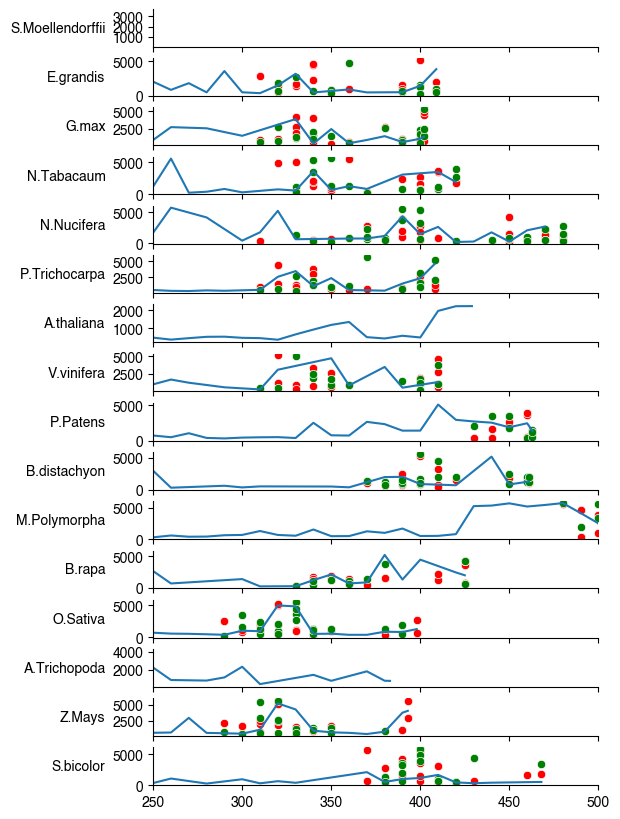

In [199]:
fig, axs = plt.subplots(16,1, figsize = (6, 8),  sharex = True)

names = list(set(wt_basic_tiles["standard_name"]))

for i in np.arange(16):
    sns.lineplot(data = wt_basic_tiles[wt_basic_tiles["standard_name"] == names[i]], x = "mid", y = "Activity_S3_1", ax = axs[i])
    sns.scatterplot(data = basic_PSv_SingleA_with_wt[basic_PSv_SingleA_with_wt["standard_name"] == names[i]], x = "mid", y = "Activity_S3_1_var", ax = axs[i], color = 'red')
    sns.scatterplot(data = basic_PSv_SingleD_with_wt[basic_PSv_SingleD_with_wt["standard_name"] == names[i]], x = "mid", y = "Activity_S3_1_var", ax = axs[i], color = 'green')
    
    axs[i].set_ylabel(names[i], rotation = 0, labelpad = 5, ha = 'right', va = 'center')
    axs[i].set_xlabel("")
    
    axs[i].set_xlim(250, 500)

sns.despine()
plt.tight_layout(pad = 0)

In [210]:
ortholog_tile_activities = pd.read_csv("../data/sog1_orthologs_tile_activities.csv", index_col = 0)
ortholog_tile_activities["DBD_adj"] = ortholog_tile_activities["adj_mid"] - ortholog_tile_activities["mid"] 
ortholog_tile_activities["name"] = ortholog_tile_activities["name"].str.split(" ").str[0]
DBD_adj = pd.merge(ortholog_tile_activities, ortholog_name_mapping, on = 'name')[["standard_name", "DBD_adj"]].drop_duplicates()
DBD_adj = dict(zip(DBD_adj["standard_name"], DBD_adj["DBD_adj"]))
DBD_adj

{'B.rapa': -146,
 'S.bicolor': -182,
 'E.grandis': -149,
 'V.vinifera': -146,
 'P.Trichocarpa': -148,
 'N.Tabacaum': -151,
 'G.max': -147,
 'S.Moellendorffii': -101,
 'M.Polymorpha': -163,
 'P.Patens': -125,
 'A.Trichopoda': -103,
 'O.Sativa': -149,
 'B.distachyon': -149,
 'Z.Mays': -148,
 'N.Nucifera': -149,
 'A.thaliana': -149}

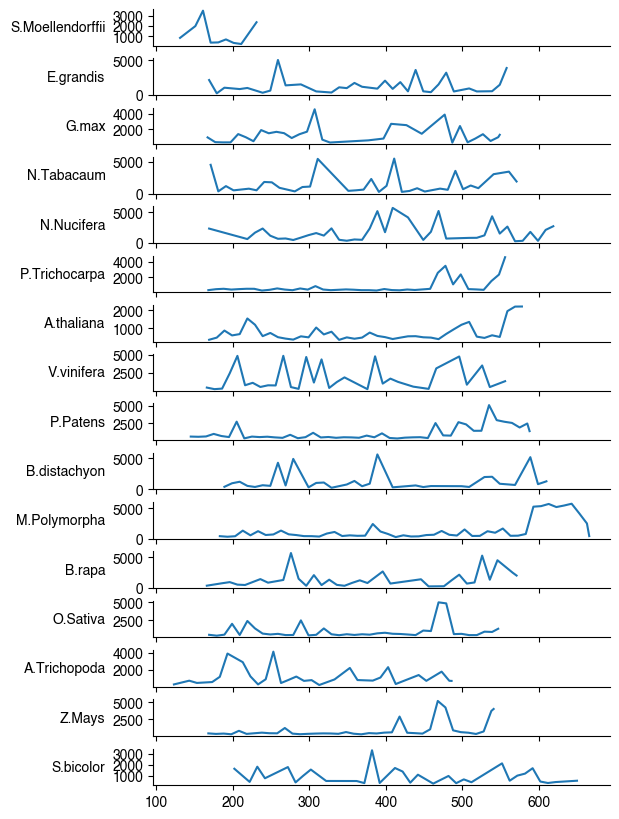

In [212]:
# DBD adj activities

fig, axs = plt.subplots(16,1, figsize = (6, 8),  sharex = True)

names = list(set(wt_basic_tiles["standard_name"]))

for i in np.arange(16):
    name = names[i]
    data = wt_basic_tiles[wt_basic_tiles["standard_name"] == name]
    sns.lineplot(x = data["mid"] - DBD_adj[name], y = data["Activity_S3_1"], ax = axs[i])
    # sns.scatterplot(data = basic_PSv_SingleA_with_wt[basic_PSv_SingleA_with_wt["standard_name"] == names[i]], x = "mid", y = "Activity_S3_1_var", ax = axs[i], color = 'red')
    # sns.scatterplot(data = basic_PSv_SingleD_with_wt[basic_PSv_SingleD_with_wt["standard_name"] == names[i]], x = "mid", y = "Activity_S3_1_var", ax = axs[i], color = 'green')
    
    axs[i].set_ylabel(names[i], rotation = 0, labelpad = 5, ha = 'right', va = 'center')
    axs[i].set_xlabel("")
    
    #axs[i].set_xlim(250, 500)

sns.despine()
plt.tight_layout(pad = 0)

In [213]:
basic_PSv_SingleA_with_wt["fold_change"] = basic_PSv_SingleA_with_wt["Activity_S3_1_var"] / basic_PSv_SingleA_with_wt["Activity_S3_1_wt"]
basic_PSv_SingleA_with_wt["log(fold_change)"] = np.log(basic_PSv_SingleA_with_wt["fold_change"])
basic_PSv_SingleA_with_wt

,Start,End,Description,Other,tile,Activity_S3_1_var,Activity_S3_2,lib2_avg,name,Tile_Description,mid,Description_name,standard_name,var,Activity_S3_1_wt,fold_change,log(fold_change)
0,311,350,BasicBrRa.32_PSv_SingleA_S342A,B.rapa_Brara.G00896.1.p_Macovei_single_pmut_si...,HDKEDENDQENKEGEENHQAEEEENLLDSGGAQFILNSQQ,214.750942,283.633576,249.192259,B.rapa,BasicBrRa.32,330,BasicBrRa,B.rapa,S342A,280.697444,0.765062,-0.267798
1,311,350,BasicBrRa.32_PSv_SingleA_S348A,B.rapa_Brara.G00896.1.p_Macovei_single_pmut_si...,HDKEDENDQENKEGEENHQAEEEENLLDSGGSQFILNAQQ,291.428443,262.523352,276.975897,B.rapa,BasicBrRa.32,330,BasicBrRa,B.rapa,S348A,280.697444,1.038230,0.037517
2,321,360,BasicBrRa.33_PSv_SingleA_S342A,B.rapa_Brara.G00896.1.p_Macovei_single_pmut_si...,NKEGEENHQAEEEENLLDSGGAQFILNSQQLVEALALCDD,1668.727020,1861.429376,1765.078198,B.rapa,BasicBrRa.33,340,BasicBrRa,B.rapa,S342A,1237.121866,1.348878,0.299273
3,321,360,BasicBrRa.33_PSv_SingleA_S348A,B.rapa_Brara.G00896.1.p_Macovei_single_pmut_si...,NKEGEENHQAEEEENLLDSGGSQFILNAQQLVEALALCDD,1416.700941,1539.548591,1478.124766,B.rapa,BasicBrRa.33,340,BasicBrRa,B.rapa,S348A,1237.121866,1.145159,0.135543
4,331,370,BasicBrRa.34_PSv_SingleA_S342A,B.rapa_Brara.G00896.1.p_Macovei_single_pmut_si...,EEEENLLDSGGAQFILNSQQLVEALALCDDLLQVGSQDAN,1959.673112,1871.840662,1915.756887,B.rapa,BasicBrRa.34,350,BasicBrRa,B.rapa,S342A,2145.761387,0.913276,-0.090717
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,451,490,BasicNeSa.46_PSv_SingleA_S462A,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmut_si...,IELDTPPDFRLAQLEFESQDSYTPWVGTKVGAEWSMGANL,1171.465028,1251.071445,1211.268237,Nelumbonucifera,BasicNeSa.46,470,BasicNeSa,N.Nucifera,S462A,2696.917932,0.434372,-0.833854
275,451,490,BasicNeSa.46_PSv_SingleA_S468A,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmut_si...,IELDTPPDFRLSQLEFEAQDSYTPWVGTKVGAEWSMGANL,1374.038104,1571.714031,1472.876068,Nelumbonucifera,BasicNeSa.46,470,BasicNeSa,N.Nucifera,S468A,2696.917932,0.509485,-0.674356
276,461,500,BasicNeSa.47_PSv_SingleA_T455A,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmut_si...,LDAPPDFRLSQLEFESQDSYTPWVGTKVGAEWSMGANLTQ,1089.543302,852.694058,971.118680,Nelumbonucifera,BasicNeSa.47,480,BasicNeSa,N.Nucifera,T455A,NaN,NaN,NaN
277,461,500,BasicNeSa.47_PSv_SingleA_S462A,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmut_si...,LDTPPDFRLAQLEFESQDSYTPWVGTKVGAEWSMGANLTQ,1356.615221,1250.928285,1303.771753,Nelumbonucifera,BasicNeSa.47,480,BasicNeSa,N.Nucifera,S462A,NaN,NaN,NaN


In [214]:
avg_singleA_change = basic_PSv_SingleA_with_wt[["standard_name", "var", "log(fold_change)"]].groupby(["standard_name", "var"]).mean().reset_index()
avg_singleA_change["var_pos"] = avg_singleA_change["var"].str[1:-1].astype(int)
avg_singleA_change["DBD_adj_var_pos"] = avg_singleA_change["var_pos"] + avg_singleA_change["standard_name"].map(DBD_adj)
avg_singleA_change

,standard_name,var,log(fold_change),var_pos,DBD_adj_var_pos
0,B.distachyon,S10A,NaN,10,-139
1,B.distachyon,S384A,-0.746246,384,235
2,B.distachyon,S394A,0.346005,394,245
3,B.distachyon,S400A,1.791761,400,251
4,B.distachyon,S416A,0.353271,416,267
...,...,...,...,...,...
76,Z.Mays,S318A,0.704722,318,170
77,Z.Mays,S334A,-1.078540,334,186
78,Z.Mays,S336A,-0.535767,336,188
79,Z.Mays,S393A,-0.833685,393,245


In [217]:
basic_PSv_SingleD_with_wt["fold_change"] = basic_PSv_SingleD_with_wt["Activity_S3_1_var"] / basic_PSv_SingleD_with_wt["Activity_S3_1_wt"]
basic_PSv_SingleD_with_wt["log(fold_change)"] = np.log(basic_PSv_SingleD_with_wt["fold_change"])
basic_PSv_SingleD_with_wt

,Start,End,Description,Other,tile,Activity_S3_1_var,Activity_S3_2,lib2_avg,name,Tile_Description,mid,Description_name,standard_name,var,Activity_S3_1_wt,fold_change,log(fold_change)
0,311,350,BasicBrRa.32_PSv_SingleD_S342D,B.rapa_Brara.G00896.1.p_Macovei_single_pmim_si...,HDKEDENDQENKEGEENHQAEEEENLLDSGGDQFILNSQQ,NaN,NaN,NaN,B.rapa,BasicBrRa.32,330,BasicBrRa,B.rapa,S342D,280.697444,NaN,NaN
1,311,350,BasicBrRa.32_PSv_SingleD_S348D,B.rapa_Brara.G00896.1.p_Macovei_single_pmim_si...,HDKEDENDQENKEGEENHQAEEEENLLDSGGSQFILNDQQ,290.288186,290.777258,290.532722,B.rapa,BasicBrRa.32,330,BasicBrRa,B.rapa,S348D,280.697444,1.034168,0.033597
2,321,360,BasicBrRa.33_PSv_SingleD_S342D,B.rapa_Brara.G00896.1.p_Macovei_single_pmim_si...,NKEGEENHQAEEEENLLDSGGDQFILNSQQLVEALALCDD,451.191291,470.469181,460.830236,B.rapa,BasicBrRa.33,340,BasicBrRa,B.rapa,S342D,1237.121866,0.364710,-1.008651
3,321,360,BasicBrRa.33_PSv_SingleD_S348D,B.rapa_Brara.G00896.1.p_Macovei_single_pmim_si...,NKEGEENHQAEEEENLLDSGGSQFILNDQQLVEALALCDD,1125.199178,1206.535845,1165.867511,B.rapa,BasicBrRa.33,340,BasicBrRa,B.rapa,S348D,1237.121866,0.909530,-0.094828
4,331,370,BasicBrRa.34_PSv_SingleD_S342D,B.rapa_Brara.G00896.1.p_Macovei_single_pmim_si...,EEEENLLDSGGDQFILNSQQLVEALALCDDLLQVGSQDAN,NaN,NaN,NaN,B.rapa,BasicBrRa.34,350,BasicBrRa,B.rapa,S342D,2145.761387,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
274,451,490,BasicNeSa.46_PSv_SingleD_S462D,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmim_si...,IELDTPPDFRLDQLEFESQDSYTPWVGTKVGAEWSMGANL,604.037119,713.539977,658.788548,Nelumbonucifera,BasicNeSa.46,470,BasicNeSa,N.Nucifera,S462D,2696.917932,0.223973,-1.496229
275,451,490,BasicNeSa.46_PSv_SingleD_S468D,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmim_si...,IELDTPPDFRLSQLEFEDQDSYTPWVGTKVGAEWSMGANL,2379.836031,1883.491797,2131.663914,Nelumbonucifera,BasicNeSa.46,470,BasicNeSa,N.Nucifera,S468D,2696.917932,0.882428,-0.125078
276,461,500,BasicNeSa.47_PSv_SingleD_T455D,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmim_si...,LDDPPDFRLSQLEFESQDSYTPWVGTKVGAEWSMGANLTQ,2772.703378,3526.815676,3149.759527,Nelumbonucifera,BasicNeSa.47,480,BasicNeSa,N.Nucifera,T455D,NaN,NaN,NaN
277,461,500,BasicNeSa.47_PSv_SingleD_S462D,Nelumbonucifera_A0A1U8ABV8_TAIR_single_pmim_si...,LDTPPDFRLDQLEFESQDSYTPWVGTKVGAEWSMGANLTQ,410.573938,466.261739,438.417838,Nelumbonucifera,BasicNeSa.47,480,BasicNeSa,N.Nucifera,S462D,NaN,NaN,NaN


In [218]:
avg_singleD_change = basic_PSv_SingleD_with_wt[["standard_name", "var", "log(fold_change)"]].groupby(["standard_name", "var"]).mean().reset_index()
avg_singleD_change["var_pos"] = avg_singleD_change["var"].str[1:-1].astype(int)
avg_singleD_change["DBD_adj_var_pos"] = avg_singleD_change["var_pos"] + avg_singleD_change["standard_name"].map(DBD_adj)
avg_singleD_change

,standard_name,var,log(fold_change),var_pos,DBD_adj_var_pos
0,B.distachyon,S10D,NaN,10,-139
1,B.distachyon,S384D,-0.197374,384,235
2,B.distachyon,S394D,-0.542529,394,245
3,B.distachyon,S400D,-0.034498,400,251
4,B.distachyon,S416D,1.424497,416,267
...,...,...,...,...,...
76,Z.Mays,S318D,-0.770183,318,170
77,Z.Mays,S334D,-0.223188,334,186
78,Z.Mays,S336D,-0.810870,336,188
79,Z.Mays,S393D,0.199840,393,245


In [250]:
full_to_abbreviation_map = {
    'Vitis vinifera': 'V.vinifera',
    'Populus trichocarpa': 'P.Trichocarpa',
    'Eucalyptus grandis': 'E.grandis',
    'Glycine max': 'G.max',
    'Brassica rapa': 'B.rapa',
    'Arabidopsis thaliana': 'A.thaliana',
    'Nelumbo nucifera': 'N.Nucifera',
    'Sorghum bicolor': 'S.bicolor',
    'Zea mays': 'Z.Mays',
    'Oryza sativa': 'O.Sativa',
    'Brachypodium distachyon': 'B.distachyon',
    'Amborella trichopoda': 'A.Trichopoda',
    'Physcomitrium patens': 'P.Patens',
    'Selaginella moellendorffii': 'S.Moellendorffii',
    'Marchantia polymorpha': 'M.Polymorpha',
    'Nicotiana tabacum': 'N.Tabacaum'
}

In [251]:
from Bio import Phylo

# Species tree from https://www.ncbi.nlm.nih.gov/Taxonomy/CommonTree/wwwcmt.cgi
tree = Phylo.read("/Users/sanjanakotha/Downloads/phyliptree (1).phy", "newick")
taxon_order = []
for entry in tree.get_terminals():
   taxon_order.append(full_to_abbreviation_map[entry.name])

In [256]:
taxon_order.reverse()

In [257]:
taxon_order

['M.Polymorpha',
 'P.Patens',
 'P.Trichocarpa',
 'G.max',
 'A.thaliana',
 'B.rapa',
 'E.grandis',
 'V.vinifera',
 'N.Tabacaum',
 'N.Nucifera',
 'O.Sativa',
 'B.distachyon',
 'S.bicolor',
 'Z.Mays',
 'A.Trichopoda',
 'S.Moellendorffii']

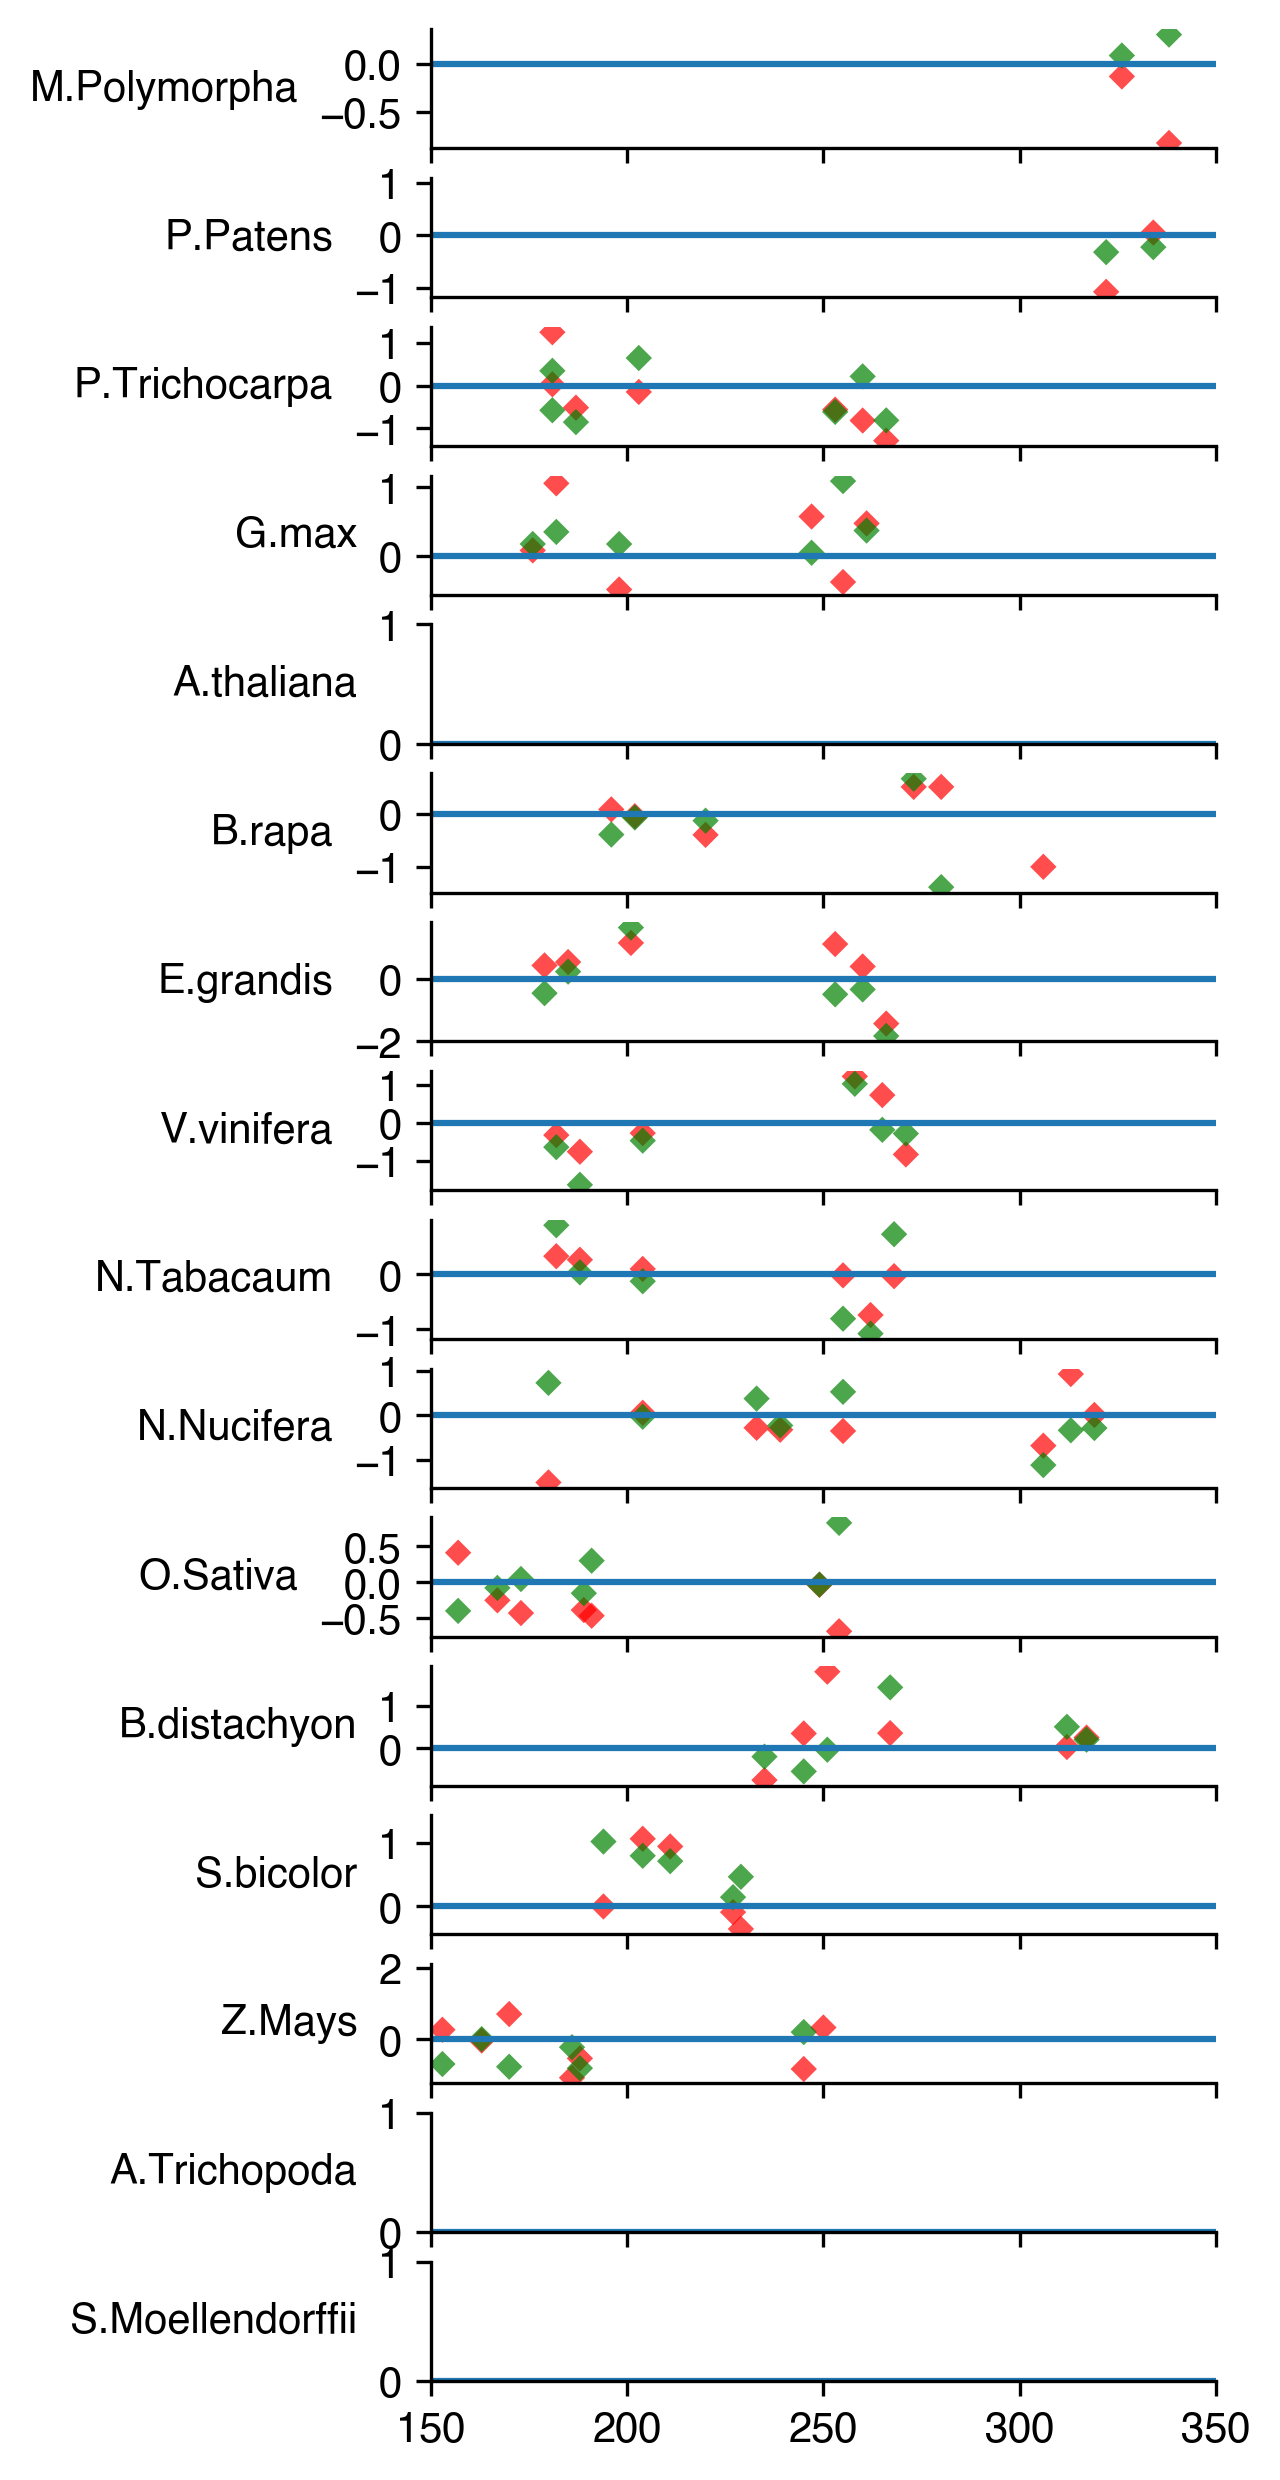

In [303]:
# DBD adj activities

fig, axs = plt.subplots(16,1, figsize = (4, 8),  sharex = True, dpi = 300)

#names = list(set(wt_basic_tiles["standard_name"]))

for i in np.arange(16):
    name = taxon_order[i]    
    data = avg_singleA_change[avg_singleA_change["standard_name"] == name]
    sns.scatterplot(x = data["DBD_adj_var_pos"], y = data["log(fold_change)"], ax = axs[i], 
                    color = 'red', edgecolor = 'none', s = 20, alpha = 0.7, marker = "D")

    data = avg_singleD_change[avg_singleD_change["standard_name"] == name]
    sns.scatterplot(x = data["DBD_adj_var_pos"], y = data["log(fold_change)"], 
                    ax = axs[i], color = 'green', edgecolor = 'none', s = 20, alpha = 0.7, marker = "D")
    
    # sns.barplot(x = data["DBD_adj_var_pos"], y = data["log(fold_change)"], 
    #                 ax = axs[i], color = 'green', native_scale = True, edgecolor = 'none', width =  0.5, 
    #             zorder = 0, alpha = 0.5)
    
    axs[i].axhline(0)
    # sns.scatterplot(data = basic_PSv_SingleA_with_wt[basic_PSv_SingleA_with_wt["standard_name"] == names[i]], x = "mid", y = "Activity_S3_1_var", ax = axs[i], color = 'red')
    # sns.scatterplot(data = basic_PSv_SingleD_with_wt[basic_PSv_SingleD_with_wt["standard_name"] == names[i]], x = "mid", y = "Activity_S3_1_var", ax = axs[i], color = 'green')
    
    axs[i].set_ylabel(name, rotation = 0, 
                      labelpad = 5, ha = 'right', va = 'center')
    axs[i].set_xlabel("")
    #axs[i].set_ylim(-2.25,2.25)
    axs[i].set_xlim(150,350)

sns.despine()
plt.tight_layout(pad = -0.25)

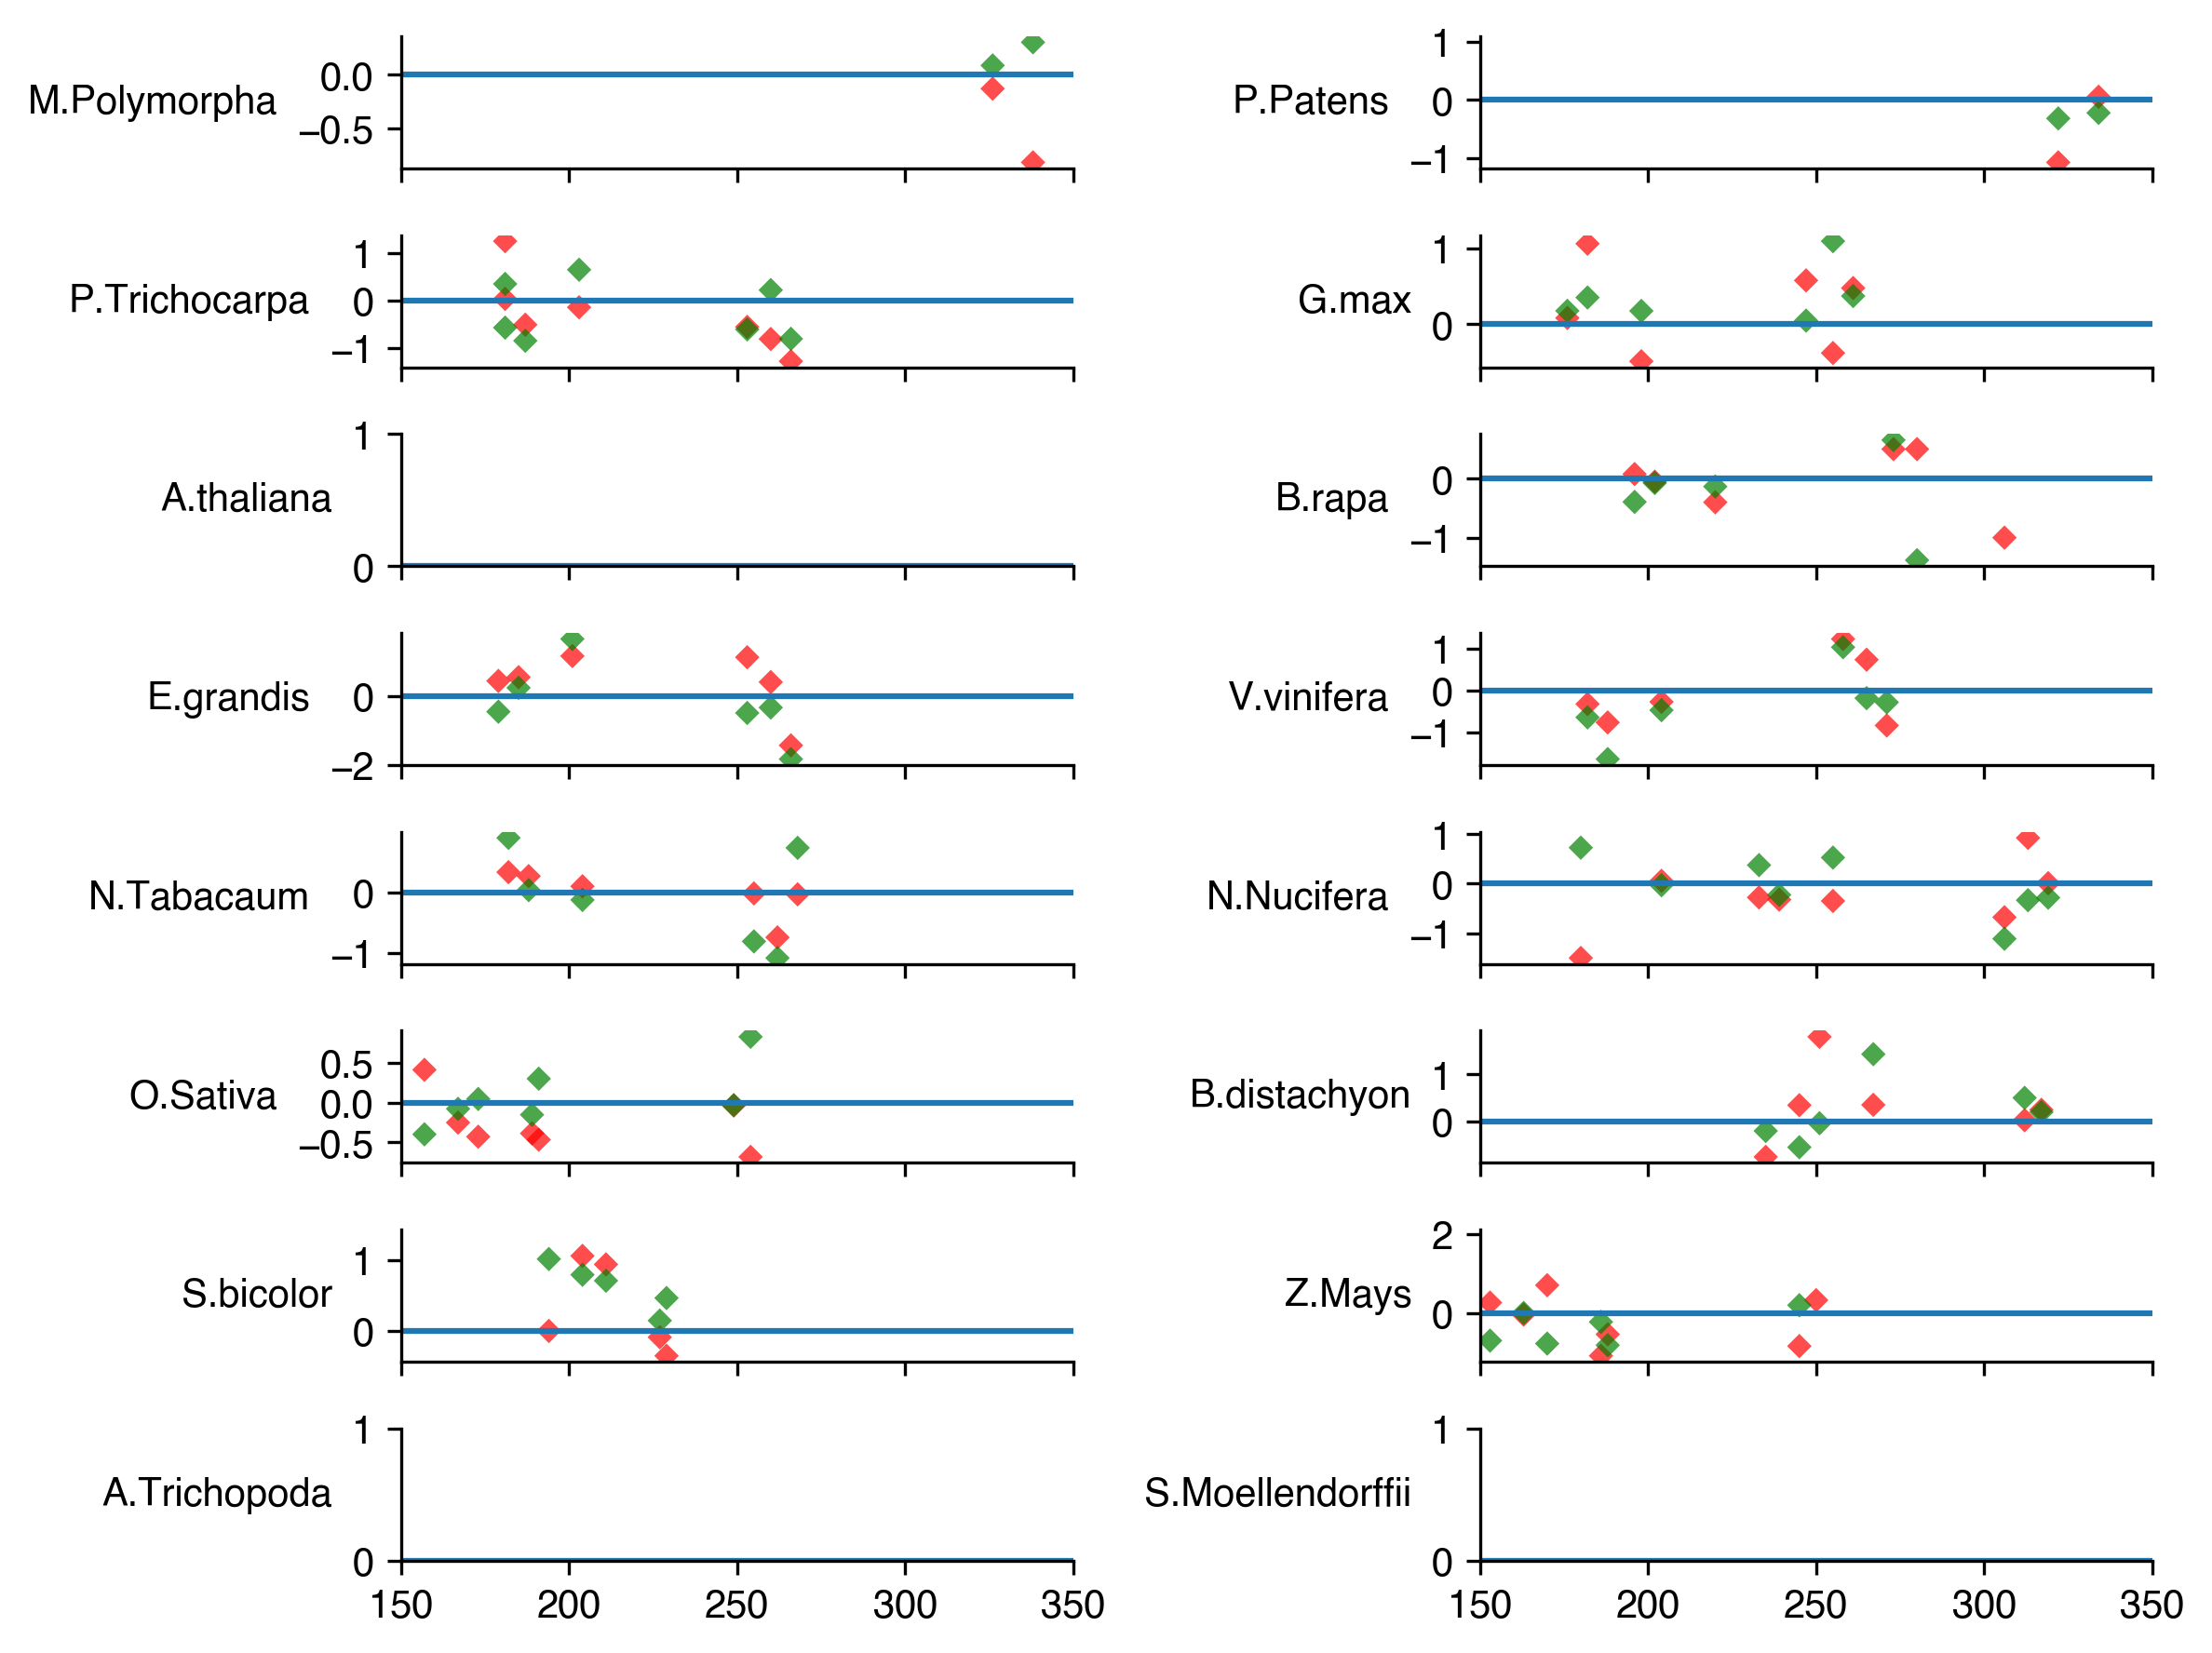

In [302]:
# DBD adj activities

fig, axs_orig = plt.subplots(8, 2, figsize = (8, 6),  sharex = True, dpi = 300)

axs =axs_orig.flatten()

#names = list(set(wt_basic_tiles["standard_name"]))

for i in np.arange(16):
    name = taxon_order[i]    
    data = avg_singleA_change[avg_singleA_change["standard_name"] == name]
    sns.scatterplot(x = data["DBD_adj_var_pos"], y = data["log(fold_change)"], ax = axs[i], 
                    color = 'red', edgecolor = 'none', s = 20, alpha = 0.7, marker = "D")

    data = avg_singleD_change[avg_singleD_change["standard_name"] == name]
    sns.scatterplot(x = data["DBD_adj_var_pos"], y = data["log(fold_change)"], 
                    ax = axs[i], color = 'green', edgecolor = 'none', s = 20, alpha = 0.7, marker = "D")
    
    # sns.barplot(x = data["DBD_adj_var_pos"], y = data["log(fold_change)"], 
    #                 ax = axs[i], color = 'green', native_scale = True, edgecolor = 'none', width =  0.5, 
    #             zorder = 0, alpha = 0.5)
    
    axs[i].axhline(0)
    # sns.scatterplot(data = basic_PSv_SingleA_with_wt[basic_PSv_SingleA_with_wt["standard_name"] == names[i]], x = "mid", y = "Activity_S3_1_var", ax = axs[i], color = 'red')
    # sns.scatterplot(data = basic_PSv_SingleD_with_wt[basic_PSv_SingleD_with_wt["standard_name"] == names[i]], x = "mid", y = "Activity_S3_1_var", ax = axs[i], color = 'green')
    
    axs[i].set_ylabel(name, rotation = 0, 
                      labelpad = 5, ha = 'right', va = 'center')
    axs[i].set_xlabel("")
    #axs[i].set_ylim(-2.25,2.25)
    axs[i].set_xlim(150,350)

sns.despine()
plt.tight_layout(pad = 1)